# **Práctica 5: Mixturas Gaussianas**

In [36]:
#Primero, se importan las librerías que se usarán
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import gc
import os
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Preprocesamiento de los datos
Primero se procesan los datos para modificar valores incorrectos (como '?' por 0) y, en definitiva, filtrar y estandarizar.
Para no sobrecargar la RAM, se ha optado por almacenar de manera local los subconjuntos con los que se trabajarán. Posteriormente, se leerán y cargarán momentáneamente en RAM.

In [37]:
CHUNK_SIZE = 50_000 # Se define el tamano de los chunks para procesar el CSV por partes, evitando cargar el dataset entero en cada iteracion
CSV_PATH   = "lichess_games.csv"
# Ademas, se especifica el nombre del fichero y de las columnas que se van a usar del CSV
COLS = ['WhiteElo', 'BlackElo', 'MovesCount', 'TimeControl']
NUM_COLS   = ['WhiteElo', 'BlackElo', 'MovesCount']

# Aqui defino una funcion para simplificar la interpretabilidad y el codigo en general del bucle que lee el dataset
# De esta manera modifico los campos necesarios
def procesar_chunk(chunk):
    #Primero, se sustituyen los valores faltantes por el valor 0 y se convierten a enteros
    chunk['WhiteElo'] = chunk['WhiteElo'].replace('?', 0).astype(int)
    chunk['BlackElo'] = chunk['BlackElo'].replace('?', 0).astype(int)

    chunk.dropna(subset=COLS, inplace=True)
    return chunk


In [38]:
# Aqui se usa el StandardScaler y el partial_fit para que el modelo aprenda de la media y desviacion tipica del dataset
scaler = StandardScaler()
for chunk in pd.read_csv(CSV_PATH, usecols=COLS, chunksize=CHUNK_SIZE):
    chunk = procesar_chunk(chunk)
    scaler.partial_fit(chunk[NUM_COLS])

# Ficheros de salida
OUTPUT_600 = "lichess_600.csv"
OUTPUT_60  = "lichess_60.csv"

# Borramos si existían de ejecuciones anteriores para no duplicar datos
for f in [OUTPUT_600, OUTPUT_60]:
    if os.path.exists(f): os.remove(f)

# Bucle principal: Procesamos y volcamos a disco
for i, chunk in enumerate(pd.read_csv(CSV_PATH, usecols=COLS, chunksize=CHUNK_SIZE)):
    chunk = procesar_chunk(chunk)

    # Se escalan las columnas numericas
    scaled_num = scaler.transform(chunk[NUM_COLS])
    scaled = pd.DataFrame(scaled_num, columns=NUM_COLS, index=chunk.index)
    scaled['TimeControl'] = chunk['TimeControl'].values

    mask_600 = chunk['TimeControl'] == '600+0'
    mask_60  = chunk['TimeControl'] == '60+0'

    # Si hay coincidencias, escribimos en modo 'append' (a)
    # Ponemos header=True solo la primera vez que se escribe el fichero
    if mask_600.any():
        scaled.loc[mask_600, NUM_COLS].to_csv(OUTPUT_600, mode='a', index=False, header=not os.path.exists(OUTPUT_600))
    if mask_60.any():
        scaled.loc[mask_60, NUM_COLS].to_csv(OUTPUT_60, mode='a', index=False, header=not os.path.exists(OUTPUT_60))
    
    # Cada 20 chunks forzamos una limpieza radical de la memoria volátil
    if i % 20 == 0:
        gc.collect()

## Desarrollo del algoritmo de mixturas Gaussianas
Para la ejecución se hará uso de la clase GaussianMixture de la librería scikit-learn. Es sencilla de aplicar:
1. Se define el modelo con el número de componentes (k) y una semilla para dar aleatoriedad.
2. Se entrena el modelo con el subconjunto correspondiente (.fit())
3. Se guardan las predicciones finales con .predict()

Nota: la predicción final que se hace, puede ser tanto para clustering duro como blando (etiquetas o probabilidades), según se indique

## Método de selección BIC (Bayesian Information Criterion)
Para aplicar este método de selección, se crea una función cuyos parámetros son: la muestra que se quiere evaluar para encontrar los $k$ componentes óptimos, y el nombre del subconjunto para el archivo y la gráfica.

In [39]:
def BIC(muestra, nmarchivo, subconjunto):
    # Probar k de 1 a 10
    k_values = range(1, 11)
    bic_scores = []

    for k in k_values:
        gmm = GaussianMixture(n_components=k, random_state=42)
        gmm.fit(muestra)
        bic_scores.append(gmm.bic(muestra))

    # Gráfica
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, bic_scores, 'bo-', label='BIC')
    plt.xlabel('Número de componentes (k)')
    plt.ylabel('Puntuación')
    plt.title(f'Selección de k óptimo para {subconjunto} - BIC')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'gmm_bic_{nmarchivo}.png', dpi=100)
    plt.show()

    # k óptimo según BIC
    k_opt = k_values[bic_scores.index(min(bic_scores))]
    print(f"k óptimo según BIC: {k_opt}")

    gc.collect()

## **Para el subconjunto '60+0'**

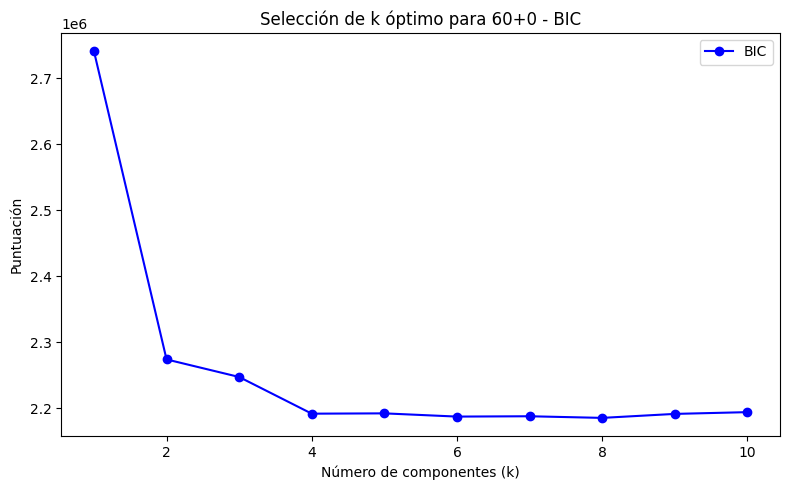

k óptimo según BIC: 8


In [40]:
# Primero se lee del archivo que contiene el subconjunto y se carga en una variable
CSV_60_PATH = "lichess_60.csv"
df_60 = pd.read_csv(CSV_60_PATH)

# uso una muestra representativa para aligerar el proceso
df_60_sample = df_60.sample(n=500_000, random_state=42)
df_60_values = df_60_sample.values
del df_60

# Calculo el k óptimo usando el método BIC
BIC(df_60_values, '60', '60+0')

Aplicando el algoritmo para **hard clustering** y un $k$ óptimo igual a $8$:

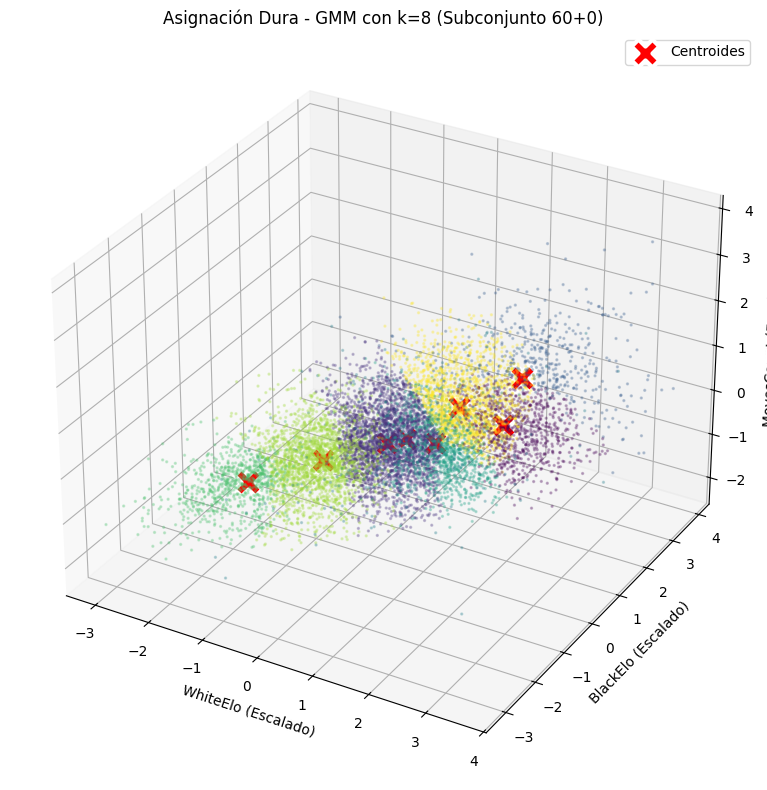

In [41]:
#-------------------------
#       ALGORITMO
#-------------------------

k_opt = 8
gmm_final = GaussianMixture(n_components=k_opt, random_state=42)
gmm_final.fit(df_60_sample)

etiquetas_duras = gmm_final.predict(df_60_sample)

centroides = gmm_final.means_

#-------------------------
#        GRÁFICA
#-------------------------
# Sacamos una muestra aleatoria solo para no saturar la gráfica al dibujar
# Usamos los índices para no perder la correspondencia entre los datos y sus etiquetas
MUESTRA_VISUAL = 10_000
idx_vis = np.random.choice(len(df_60_sample), MUESTRA_VISUAL, replace=False)

# Extraemos los datos a dibujar
datos_vis = df_60_sample.iloc[idx_vis].values
etiquetas_vis = etiquetas_duras[idx_vis]

# Configuramos la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujamos la nube de puntos. 
scatter = ax.scatter(datos_vis[:, 0], datos_vis[:, 1], datos_vis[:, 2], c=etiquetas_vis, cmap='viridis', s=2, alpha=0.25, zorder=1)

# Dibujamos los centroides
ax.scatter(centroides[:, 0], centroides[:, 1], centroides[:, 2], c='red', marker='X', s=400, linewidths=3, edgecolor='white', label='Centroides', zorder=100, depthshade=False, alpha=1.0)

ax.set_title(f'Asignación Dura - GMM con k={k_opt} (Subconjunto 60+0)')
ax.set_xlabel('WhiteElo (Escalado)')
ax.set_ylabel('BlackElo (Escalado)')
ax.set_zlabel('MovesCount (Escalado)')

# Leyenda y guardado
plt.legend()
plt.tight_layout()
plt.savefig('gmm_hard_clustering_60.png', dpi=150)
plt.show()

Aplicando el algoritmo para **soft clustering** y un $k$ óptimo igual a $8$:

C:\Users\drago\AppData\Local\Temp\ipykernel_3608\120698035.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', k_opt)


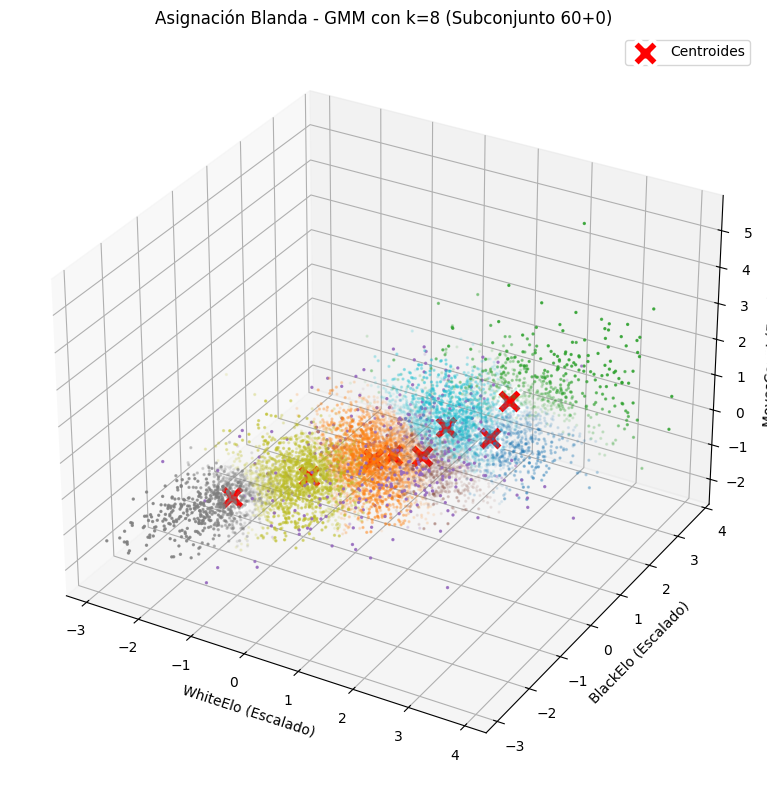

In [42]:
#-------------------------
#       ALGORITMO
#-------------------------

k_opt = 8
gmm_final = GaussianMixture(n_components=k_opt, random_state=42)
gmm_final.fit(df_60_sample)

probabilidades = gmm_final.predict_proba(df_60_sample)

centroides = gmm_final.means_

# Extraemos cluster asignado y su probabilidad
etiquetas_suaves = probabilidades.argmax(axis=1)
prob_maxima = probabilidades.max(axis=1)

#-------------------------
#        GRÁFICA
#-------------------------

MUESTRA_VISUAL = 10_000
idx_vis = np.random.choice(len(df_60_sample), MUESTRA_VISUAL, replace=False)

# Datos a dibujar
datos_vis = df_60_sample.iloc[idx_vis].values
etiquetas_vis = etiquetas_suaves[idx_vis]
probs_vis = prob_maxima[idx_vis]

# Colores e intensidad
cmap = cm.get_cmap('tab10', k_opt)
colores_rgba = cmap(etiquetas_vis)

curva_prob = probs_vis ** 4

# Se ajusta la intensidad del color a la probabilidad
alpha_min, alpha_max = 0.05, 0.8
colores_rgba[:, 3] = alpha_min + (curva_prob * (alpha_max - alpha_min))

# Configuramos la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujamos la nube de puntos
scatter = ax.scatter(datos_vis[:, 0], datos_vis[:, 1], datos_vis[:, 2], c=colores_rgba, s=2, zorder=1, depthshade=False)

# Dibujamos los centroides
ax.scatter(centroides[:, 0], centroides[:, 1], centroides[:, 2], c='red', marker='X', s=400, linewidths=3, edgecolor='white', label='Centroides', zorder=100, depthshade=False, alpha=1.0)

ax.set_title(f'Asignación Blanda - GMM con k={k_opt} (Subconjunto 60+0)')
ax.set_xlabel('WhiteElo (Escalado)')
ax.set_ylabel('BlackElo (Escalado)')
ax.set_zlabel('MovesCount (Escalado)')

# Leyenda y guardado
plt.legend()
plt.tight_layout()
plt.savefig('gmm_soft_clustering_60.png', dpi=150)
plt.show()

## **Para el subconjunto '600+0'**

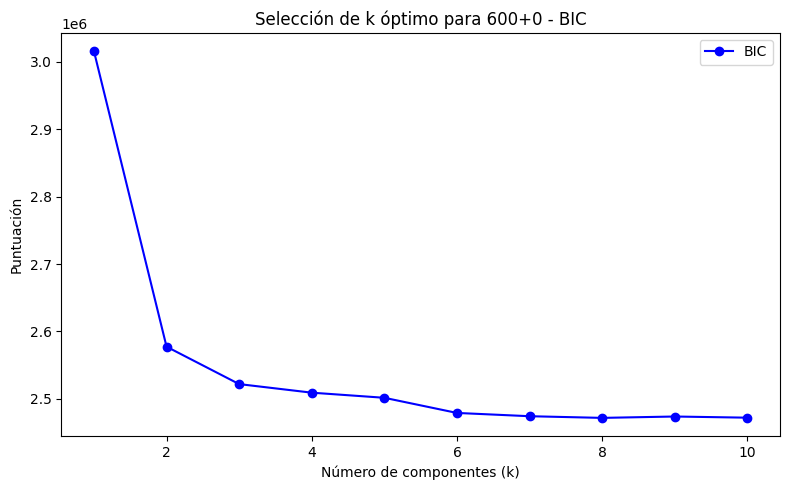

k óptimo según BIC: 8


In [43]:
CSV_600_PATH = "lichess_600.csv"
df_600 = pd.read_csv(CSV_600_PATH)

# uso una muestra representativa para aligerar el proceso
df_600_sample = df_600.sample(n=500_000, random_state=42)
df_600_values = df_600_sample.values
del df_600

BIC(df_600_values, '600', '600+0')

Aplicando el algoritmo para **hard clustering** y un $k$ óptimo igual a $8$:

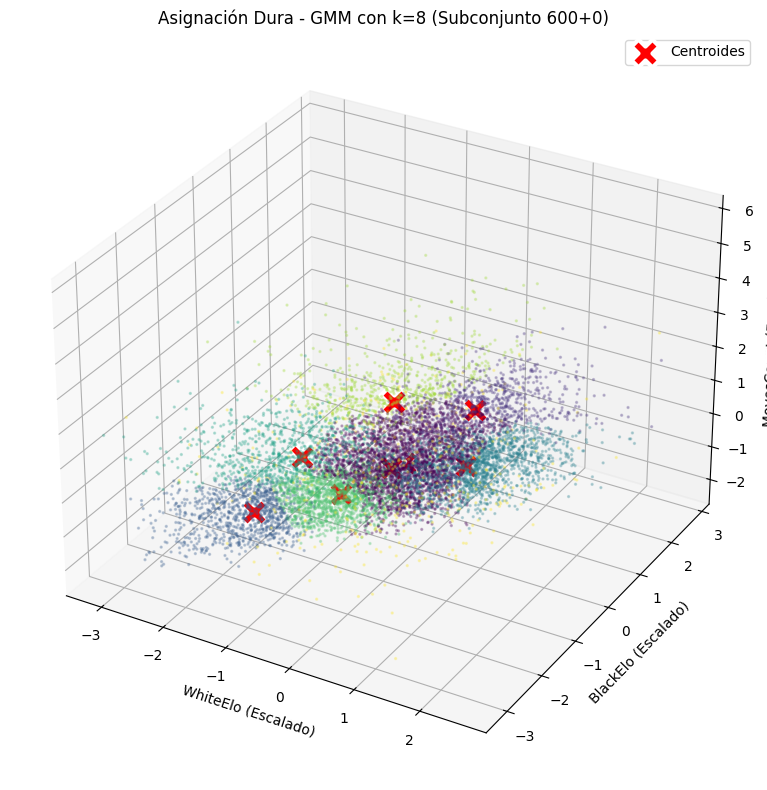

In [44]:
#-------------------------
#       ALGORITMO
#-------------------------

k_opt = 8
gmm_final = GaussianMixture(n_components=k_opt, random_state=42)
gmm_final.fit(df_600_sample)

etiquetas_duras = gmm_final.predict(df_600_sample)

centroides = gmm_final.means_

#-------------------------
#        GRÁFICA
#-------------------------

MUESTRA_VISUAL = 10_000
idx_vis = np.random.choice(len(df_600_sample), MUESTRA_VISUAL, replace=False)

# Extraemos los datos a dibujar
datos_vis = df_600_sample.iloc[idx_vis].values
etiquetas_vis = etiquetas_duras[idx_vis]

# Configuramos la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujamos la nube de puntos. 
scatter = ax.scatter(datos_vis[:, 0], datos_vis[:, 1], datos_vis[:, 2], c=etiquetas_vis, cmap='viridis', s=2, alpha=0.25, zorder=1)

# Dibujamos los centroides
ax.scatter(centroides[:, 0], centroides[:, 1], centroides[:, 2], c='red', marker='X', s=400, linewidths=3, edgecolor='white', label='Centroides', zorder=100, depthshade=False, alpha=1.0)

ax.set_title(f'Asignación Dura - GMM con k={k_opt} (Subconjunto 600+0)')
ax.set_xlabel('WhiteElo (Escalado)')
ax.set_ylabel('BlackElo (Escalado)')
ax.set_zlabel('MovesCount (Escalado)')

# Leyenda y guardado
plt.legend()
plt.tight_layout()
plt.savefig('gmm_hard_clustering_600.png', dpi=150)
plt.show()

Aplicando el algoritmo para **soft clustering** y un $k$ óptimo igual a $8$:

C:\Users\drago\AppData\Local\Temp\ipykernel_3608\843940651.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', k_opt)


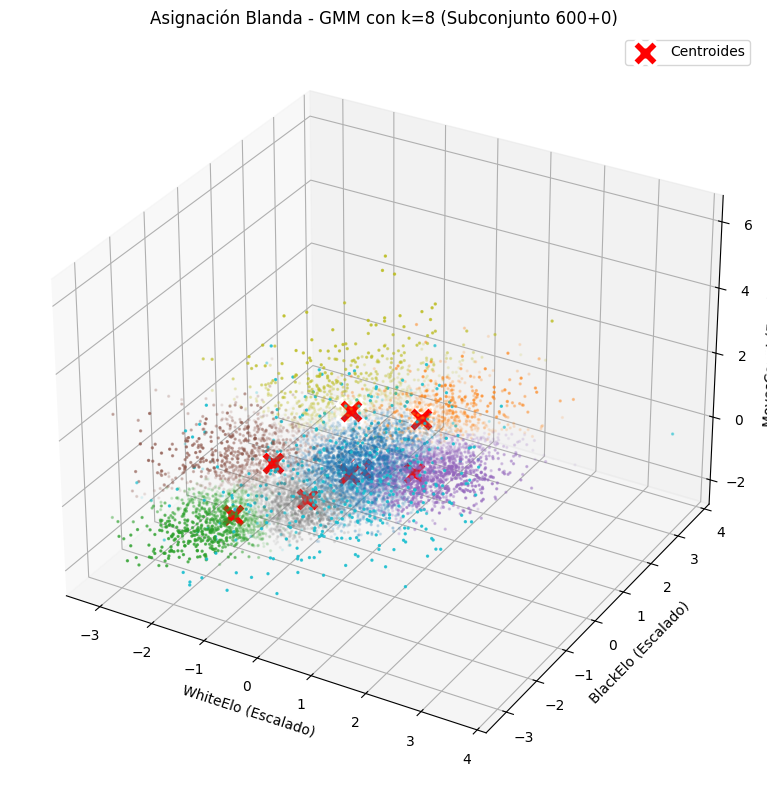

In [45]:
#-------------------------
#       ALGORITMO
#-------------------------

k_opt = 8
gmm_final = GaussianMixture(n_components=k_opt, random_state=42)
gmm_final.fit(df_600_sample)

probabilidades = gmm_final.predict_proba(df_600_sample)

centroides = gmm_final.means_

# Extraemos cluster asignado y su probabilidad
etiquetas_suaves = probabilidades.argmax(axis=1)
prob_maxima = probabilidades.max(axis=1)

#-------------------------
#        GRÁFICA
#-------------------------

MUESTRA_VISUAL = 10_000
idx_vis = np.random.choice(len(df_600_sample), MUESTRA_VISUAL, replace=False)

# Datos a dibujar
datos_vis = df_600_sample.iloc[idx_vis].values
etiquetas_vis = etiquetas_suaves[idx_vis]
probs_vis = prob_maxima[idx_vis]

# Colores e intensidad
cmap = cm.get_cmap('tab10', k_opt)
colores_rgba = cmap(etiquetas_vis)

curva_prob = probs_vis ** 4

# Se ajusta la intensidad del color a la probabilidad
alpha_min, alpha_max = 0.05, 0.8
colores_rgba[:, 3] = alpha_min + (curva_prob * (alpha_max - alpha_min))

# Configuramos la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujamos la nube de puntos
scatter = ax.scatter(datos_vis[:, 0], datos_vis[:, 1], datos_vis[:, 2], c=colores_rgba, s=2, zorder=1, depthshade=False)

# Dibujamos los centroides
ax.scatter(centroides[:, 0], centroides[:, 1], centroides[:, 2], c='red', marker='X', s=400, linewidths=3, edgecolor='white', label='Centroides', zorder=100, depthshade=False, alpha=1.0)

ax.set_title(f'Asignación Blanda - GMM con k={k_opt} (Subconjunto 600+0)')
ax.set_xlabel('WhiteElo (Escalado)')
ax.set_ylabel('BlackElo (Escalado)')
ax.set_zlabel('MovesCount (Escalado)')

# Leyenda y guardado
plt.legend()
plt.tight_layout()
plt.savefig('gmm_soft_clustering_600.png', dpi=150)
plt.show()

## Adición columnas GameElo y EloDiff
Se añadirán a los subconjuntos los siguientes atributos calculados:
- $GameElo = CEIL((WhiteElo/BlackElo)/2)$
- $EloDiff = |WhiteElo - BlackElo|$

In [46]:
NUM_COLS_EXT = ['WhiteElo', 'BlackElo', 'MovesCount', 'GameElo', 'EloDiff']

def add_derived(chunk):
    chunk['GameElo'] = np.ceil((chunk['WhiteElo'] + chunk['BlackElo']) / 2).astype(int)
    chunk['EloDiff']  = (chunk['WhiteElo'] - chunk['BlackElo']).abs()
    return chunk

# Fit del scaler con las nuevas columnas extendidas
scaler_ext = StandardScaler()
for chunk in pd.read_csv(CSV_PATH, usecols=COLS, chunksize=CHUNK_SIZE):
    chunk = procesar_chunk(chunk)
    chunk = add_derived(chunk)
    scaler_ext.partial_fit(chunk[NUM_COLS_EXT])

# Ficheros de salida
OUTPUT_600_EXT = "lichess_600_ext.csv"
OUTPUT_60_EXT  = "lichess_60_ext.csv"

# Borramos si existían de ejecuciones anteriores para no duplicar datos
for f in [OUTPUT_600_EXT, OUTPUT_60_EXT]:
    if os.path.exists(f): os.remove(f)

# Bucle principal: Procesamos y volcamos a disco
for i, chunk in enumerate(pd.read_csv(CSV_PATH, usecols=COLS, chunksize=CHUNK_SIZE)):
    chunk = procesar_chunk(chunk)
    chunk = add_derived(chunk)

    # Se escalan las columnas numericas
    scaled_num = scaler_ext.transform(chunk[NUM_COLS_EXT])
    scaled = pd.DataFrame(scaled_num, columns=NUM_COLS_EXT, index=chunk.index)
    scaled['TimeControl'] = chunk['TimeControl'].values

    mask_600_ext = chunk['TimeControl'] == '600+0'
    mask_60_ext  = chunk['TimeControl'] == '60+0'

    # Si hay coincidencias, escribimos en modo 'append' (a)
    # Ponemos header=True solo la primera vez que se escribe el fichero
    if mask_600_ext.any():
        scaled.loc[mask_600_ext, NUM_COLS_EXT].to_csv(OUTPUT_600_EXT, mode='a', index=False, header=not os.path.exists(OUTPUT_600_EXT))
    if mask_60_ext.any():
        scaled.loc[mask_60_ext, NUM_COLS_EXT].to_csv(OUTPUT_60_EXT, mode='a', index=False, header=not os.path.exists(OUTPUT_60_EXT))
    
    # Cada 20 chunks forzamos una limpieza radical de la memoria volátil
    if i % 20 == 0:
        gc.collect()

## **Para el subconjunto '60+0' extendido**

Se calcula el $k$ óptimo:

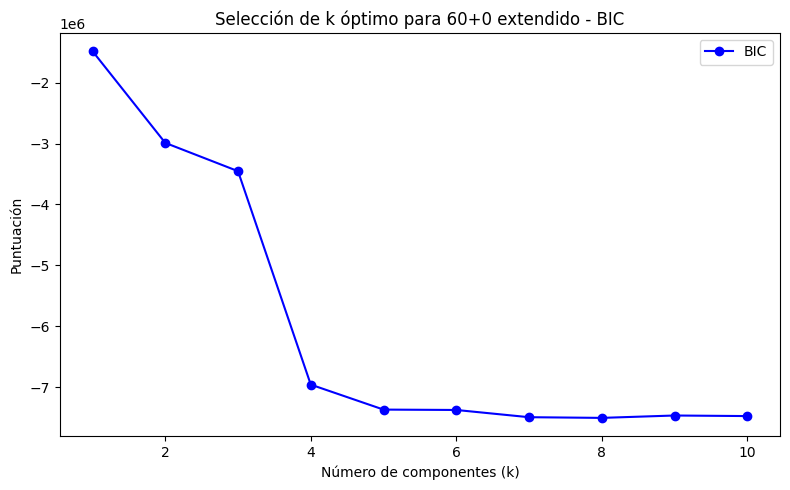

k óptimo según BIC: 8


In [47]:
CSV_60_EXT_PATH = "lichess_60_ext.csv"
df_60_ext = pd.read_csv(CSV_60_EXT_PATH)

# uso una muestra representativa para aligerar el proceso
df_60_ext_sample = df_60_ext.sample(n=500_000, random_state=42)
df_60_ext_values = df_60_ext_sample.values
del df_60_ext

BIC(df_60_ext_values, '60_ext', '60+0 extendido')

Aplicando el algoritmo para **hard clustering** y $k=8$:

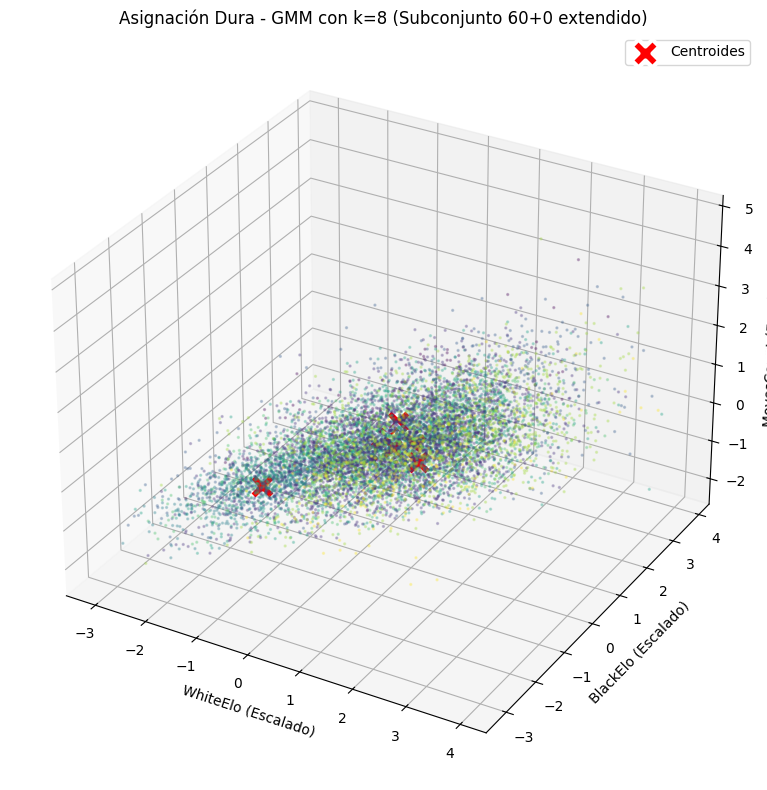

In [48]:
#-------------------------
#       ALGORITMO
#-------------------------

k_opt = 8
gmm_final = GaussianMixture(n_components=k_opt, random_state=42)
gmm_final.fit(df_60_ext_sample)

etiquetas_duras = gmm_final.predict(df_60_ext_sample)

centroides = gmm_final.means_

#-------------------------
#        GRÁFICA
#-------------------------

MUESTRA_VISUAL = 10_000
idx_vis = np.random.choice(len(df_60_ext_sample), MUESTRA_VISUAL, replace=False)

# Extraemos los datos a dibujar
datos_vis = df_60_ext_sample.iloc[idx_vis].values
etiquetas_vis = etiquetas_duras[idx_vis]

# Configuramos la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujamos la nube de puntos. 
scatter = ax.scatter(datos_vis[:, 0], datos_vis[:, 1], datos_vis[:, 2], c=etiquetas_vis, cmap='viridis', s=2, alpha=0.25, zorder=1)

# Dibujamos los centroides
ax.scatter(centroides[:, 0], centroides[:, 1], centroides[:, 2], c='red', marker='X', s=400, linewidths=3, edgecolor='white', label='Centroides', zorder=100, depthshade=False, alpha=1.0)

ax.set_title(f'Asignación Dura - GMM con k={k_opt} (Subconjunto 60+0 extendido)')
ax.set_xlabel('WhiteElo (Escalado)')
ax.set_ylabel('BlackElo (Escalado)')
ax.set_zlabel('MovesCount (Escalado)')

# Leyenda y guardado
plt.legend()
plt.tight_layout()
plt.savefig('gmm_hard_clustering_60_ext.png', dpi=150)
plt.show()

Aplicando el algoritmo para **soft clustering** y $k=8$:

C:\Users\drago\AppData\Local\Temp\ipykernel_3608\110711410.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', k_opt)


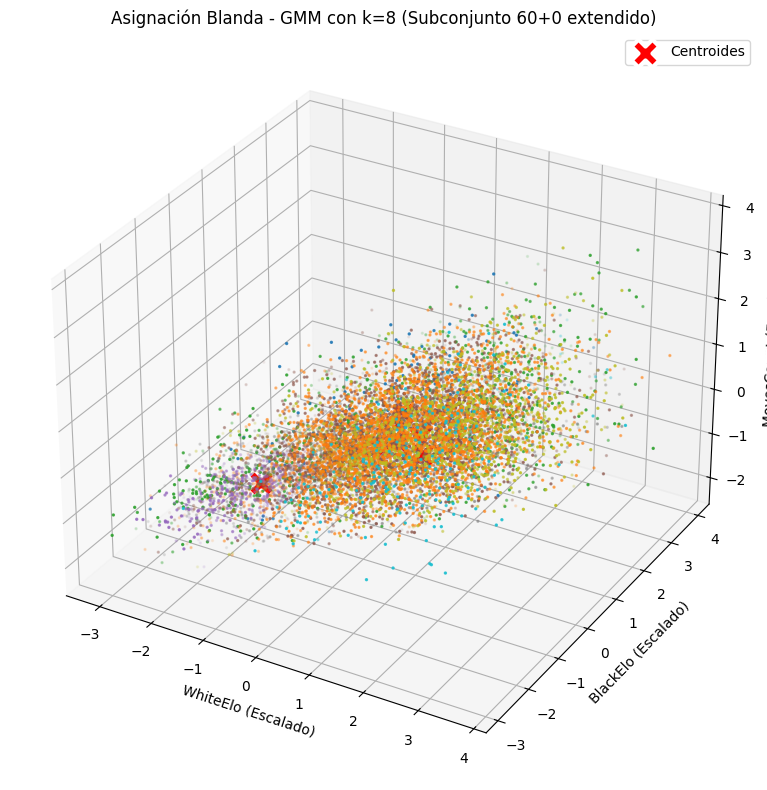

In [49]:
#-------------------------
#       ALGORITMO
#-------------------------

k_opt = 8
gmm_final = GaussianMixture(n_components=k_opt, random_state=42)
gmm_final.fit(df_60_ext_sample)

probabilidades = gmm_final.predict_proba(df_60_ext_sample)

centroides = gmm_final.means_

# Extraemos cluster asignado y su probabilidad
etiquetas_suaves = probabilidades.argmax(axis=1)
prob_maxima = probabilidades.max(axis=1)

#-------------------------
#        GRÁFICA
#-------------------------

MUESTRA_VISUAL = 10_000
idx_vis = np.random.choice(len(df_60_ext_sample), MUESTRA_VISUAL, replace=False)

# Datos a dibujar
datos_vis = df_60_ext_sample.iloc[idx_vis].values
etiquetas_vis = etiquetas_suaves[idx_vis]
probs_vis = prob_maxima[idx_vis]

# Colores e intensidad
cmap = cm.get_cmap('tab10', k_opt)
colores_rgba = cmap(etiquetas_vis)

curva_prob = probs_vis ** 4

# Se ajusta la intensidad del color a la probabilidad
alpha_min, alpha_max = 0.05, 0.8
colores_rgba[:, 3] = alpha_min + (curva_prob * (alpha_max - alpha_min))

# Configuramos la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujamos la nube de puntos
scatter = ax.scatter(datos_vis[:, 0], datos_vis[:, 1], datos_vis[:, 2], c=colores_rgba, s=2, zorder=1, depthshade=False)

# Dibujamos los centroides
ax.scatter(centroides[:, 0], centroides[:, 1], centroides[:, 2], c='red', marker='X', s=400, linewidths=3, edgecolor='white', label='Centroides', zorder=100, depthshade=False, alpha=1.0)

ax.set_title(f'Asignación Blanda - GMM con k={k_opt} (Subconjunto 60+0 extendido)')
ax.set_xlabel('WhiteElo (Escalado)')
ax.set_ylabel('BlackElo (Escalado)')
ax.set_zlabel('MovesCount (Escalado)')

# Leyenda y guardado
plt.legend()
plt.tight_layout()
plt.savefig('gmm_soft_clustering_60_ext.png', dpi=150)
plt.show()

## PCA
Ahora llega el momento de aplicar el PCA para los dos subconjuntos con la extensión de las columnas.
Es más eficiente implementarlo dentro de una función para modificar el parámetro "variance" según se necesite, además, no solo aplica el PCA sino que genera también la gráfica.

In [50]:
def pca(X, k, varianza, titulo, nombre_archivo):
    """
    Aplica PCA para reducir dimensionalidad, entrena un GMM sobre el espacio reducido
    y genera un gráfico 2D con los resultados.
    """

    # Filtro PCA
    pca = PCA(n_components=varianza, random_state=42)
    X_pca = pca.fit_transform(X)
    
    # Entrenamiento GMM sobre los datos limpios
    gmm = GaussianMixture(n_components=k, random_state=42)
    etiquetas = gmm.fit_predict(X_pca)
    centroides = gmm.means_
    
    # Submuestreo para proteger la memoria RAM al graficar
    MUESTRA_VISUAL = min(10_000, len(X_pca)) 
    idx_vis = np.random.choice(len(X_pca), MUESTRA_VISUAL, replace=False)
    
    datos_vis = X_pca[idx_vis]
    etiquetas_vis = etiquetas[idx_vis]
    
    # Generación de la gráfica 2D
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Dibujamos las componentes 1 y 2
    scatter = ax.scatter(datos_vis[:, 0], datos_vis[:, 1], 
                         c=etiquetas_vis, cmap='tab10', s=10, alpha=0.5)
    
    # Dibujamos los centroides
    ax.scatter(centroides[:, 0], centroides[:, 1], 
               c='red', marker='X', s=300, edgecolor='black', linewidths=2, 
               label='Centroides', zorder=10)
    
    ax.set_title(titulo)
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=150)
    plt.show()
    plt.close(fig) # Cerramos la figura para liberar memoria

PCA 0.95:

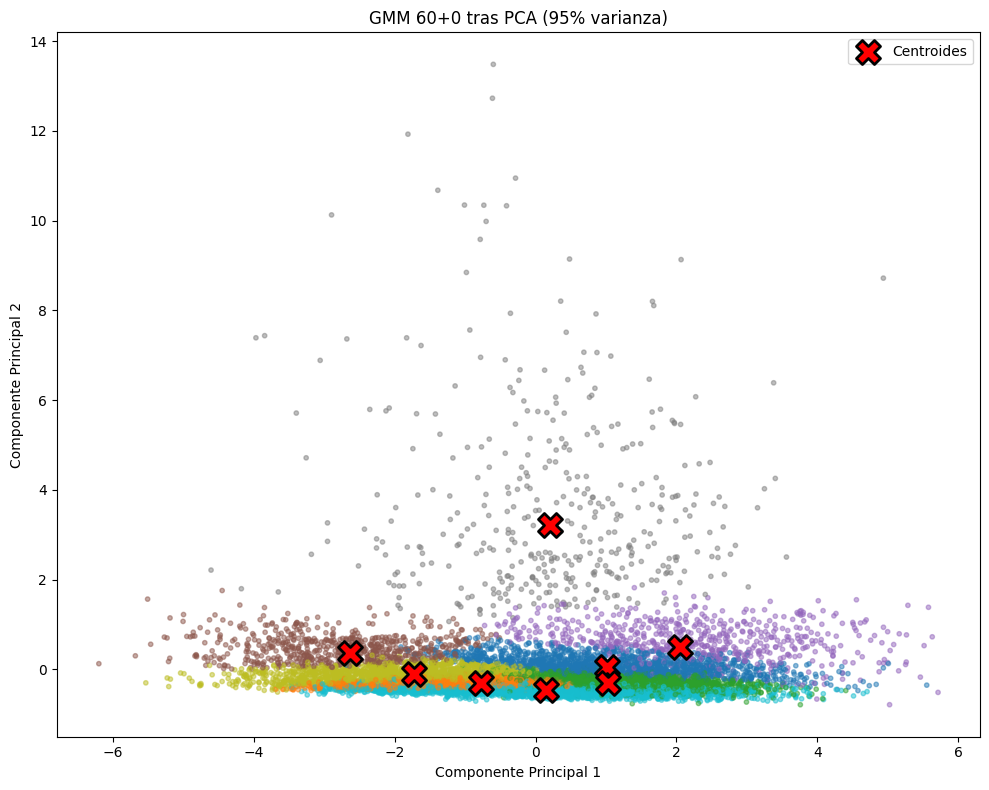

In [51]:
pca(df_60_ext_sample, 8, 0.95, 'GMM 60+0 tras PCA (95% varianza)', nombre_archivo = 'gmm_60_ext_pca_095.png')

PCA 0.80:

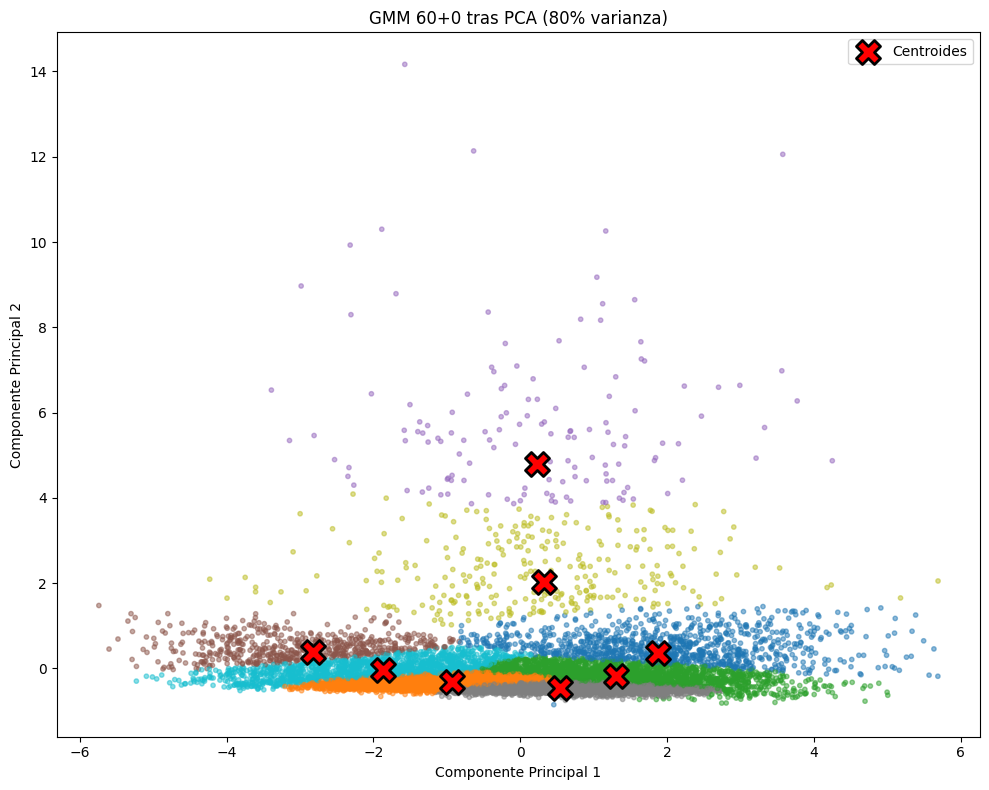

In [52]:
pca(df_60_ext_sample, 8, 0.8, 'GMM 60+0 tras PCA (80% varianza)', nombre_archivo = 'gmm_60_ext_pca_080.png')

## **Para el subconjunto '600+0' extendido**

Se calcula el $k$ óptimo:

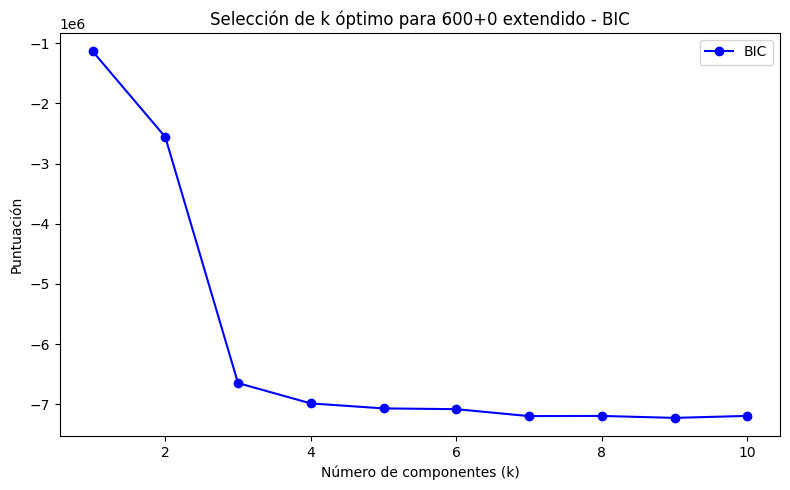

k óptimo según BIC: 9


In [53]:
CSV_600_EXT_PATH = "lichess_600_ext.csv"
df_600_ext = pd.read_csv(CSV_600_EXT_PATH)

# uso una muestra representativa para aligerar el proceso
df_600_ext_sample = df_600_ext.sample(n=500_000, random_state=42)
df_600_ext_values = df_600_ext_sample.values
del df_600_ext

BIC(df_600_ext_values, '600_ext', '600+0 extendido')

Aplicando el algoritmo para **hard clustering** y $k=9$:

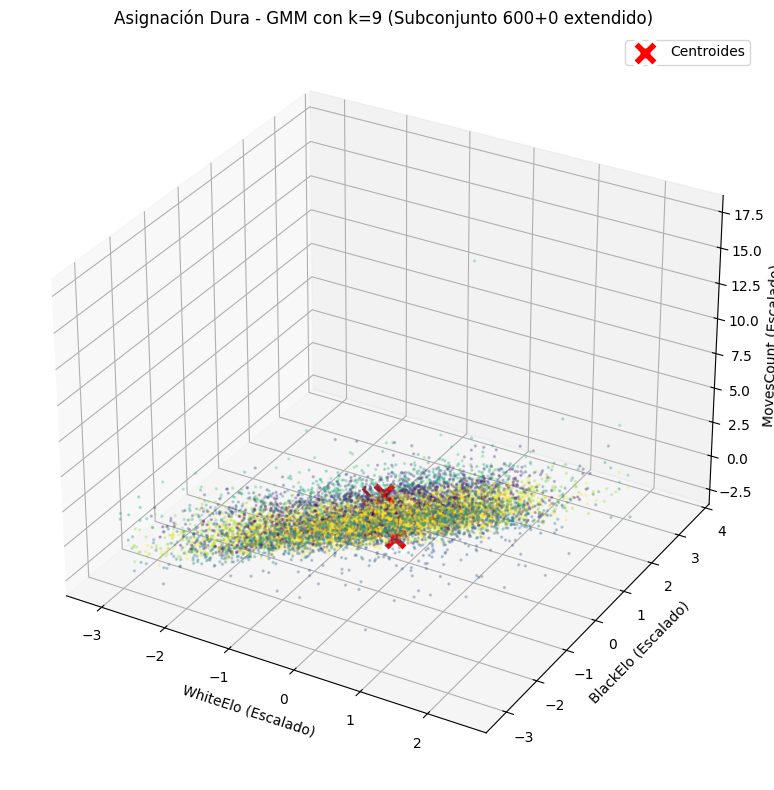

In [54]:
#-------------------------
#       ALGORITMO
#-------------------------

k_opt_600_ext = 9
gmm_final = GaussianMixture(n_components=k_opt, random_state=42)
gmm_final.fit(df_600_ext_sample)

etiquetas_duras = gmm_final.predict(df_600_ext_sample)

centroides = gmm_final.means_

#-------------------------
#        GRÁFICA
#-------------------------

MUESTRA_VISUAL = 10_000
idx_vis = np.random.choice(len(df_600_ext_sample), MUESTRA_VISUAL, replace=False)

# Extraemos los datos a dibujar
datos_vis = df_600_ext_sample.iloc[idx_vis].values
etiquetas_vis = etiquetas_duras[idx_vis]

# Configuramos la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujamos la nube de puntos. 
scatter = ax.scatter(datos_vis[:, 0], datos_vis[:, 1], datos_vis[:, 2], c=etiquetas_vis, cmap='viridis', s=2, alpha=0.25, zorder=1)

# Dibujamos los centroides
ax.scatter(centroides[:, 0], centroides[:, 1], centroides[:, 2], c='red', marker='X', s=400, linewidths=3, edgecolor='white', label='Centroides', zorder=100, depthshade=False, alpha=1.0)

ax.set_title(f'Asignación Dura - GMM con k={k_opt_600_ext} (Subconjunto 600+0 extendido)')
ax.set_xlabel('WhiteElo (Escalado)')
ax.set_ylabel('BlackElo (Escalado)')
ax.set_zlabel('MovesCount (Escalado)')

# Leyenda y guardado
plt.legend()
plt.tight_layout()
plt.savefig('gmm_hard_clustering_600_ext.png', dpi=150)
plt.show()

Aplicando el algoritmo para **soft clustering** y $k=9$:

C:\Users\drago\AppData\Local\Temp\ipykernel_3608\4213451676.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', k_opt)


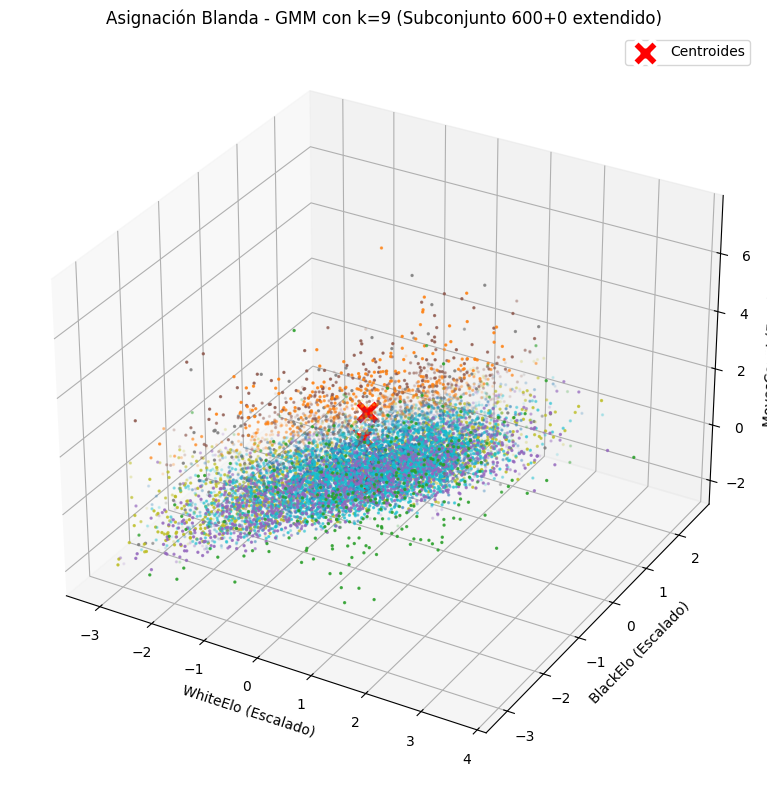

In [55]:
#-------------------------
#       ALGORITMO
#-------------------------

k_opt_600_ext = 9
gmm_final = GaussianMixture(n_components=k_opt, random_state=42)
gmm_final.fit(df_600_ext_sample)

probabilidades = gmm_final.predict_proba(df_600_ext_sample)

centroides = gmm_final.means_

# Extraemos cluster asignado y su probabilidad
etiquetas_suaves = probabilidades.argmax(axis=1)
prob_maxima = probabilidades.max(axis=1)

#-------------------------
#        GRÁFICA
#-------------------------

MUESTRA_VISUAL = 10_000
idx_vis = np.random.choice(len(df_600_ext_sample), MUESTRA_VISUAL, replace=False)

# Datos a dibujar
datos_vis = df_600_ext_sample.iloc[idx_vis].values
etiquetas_vis = etiquetas_suaves[idx_vis]
probs_vis = prob_maxima[idx_vis]

# Colores e intensidad
cmap = cm.get_cmap('tab10', k_opt)
colores_rgba = cmap(etiquetas_vis)

curva_prob = probs_vis ** 4

# Se ajusta la intensidad del color a la probabilidad
alpha_min, alpha_max = 0.05, 0.8
colores_rgba[:, 3] = alpha_min + (curva_prob * (alpha_max - alpha_min))

# Configuramos la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujamos la nube de puntos
scatter = ax.scatter(datos_vis[:, 0], datos_vis[:, 1], datos_vis[:, 2], c=colores_rgba, s=2, zorder=1, depthshade=False)

# Dibujamos los centroides
ax.scatter(centroides[:, 0], centroides[:, 1], centroides[:, 2], c='red', marker='X', s=400, linewidths=3, edgecolor='white', label='Centroides', zorder=100, depthshade=False, alpha=1.0)

ax.set_title(f'Asignación Blanda - GMM con k={k_opt_600_ext} (Subconjunto 600+0 extendido)')
ax.set_xlabel('WhiteElo (Escalado)')
ax.set_ylabel('BlackElo (Escalado)')
ax.set_zlabel('MovesCount (Escalado)')

# Leyenda y guardado
plt.legend()
plt.tight_layout()
plt.savefig('gmm_soft_clustering_600_ext.png', dpi=150)
plt.show()

PCA 0.95:

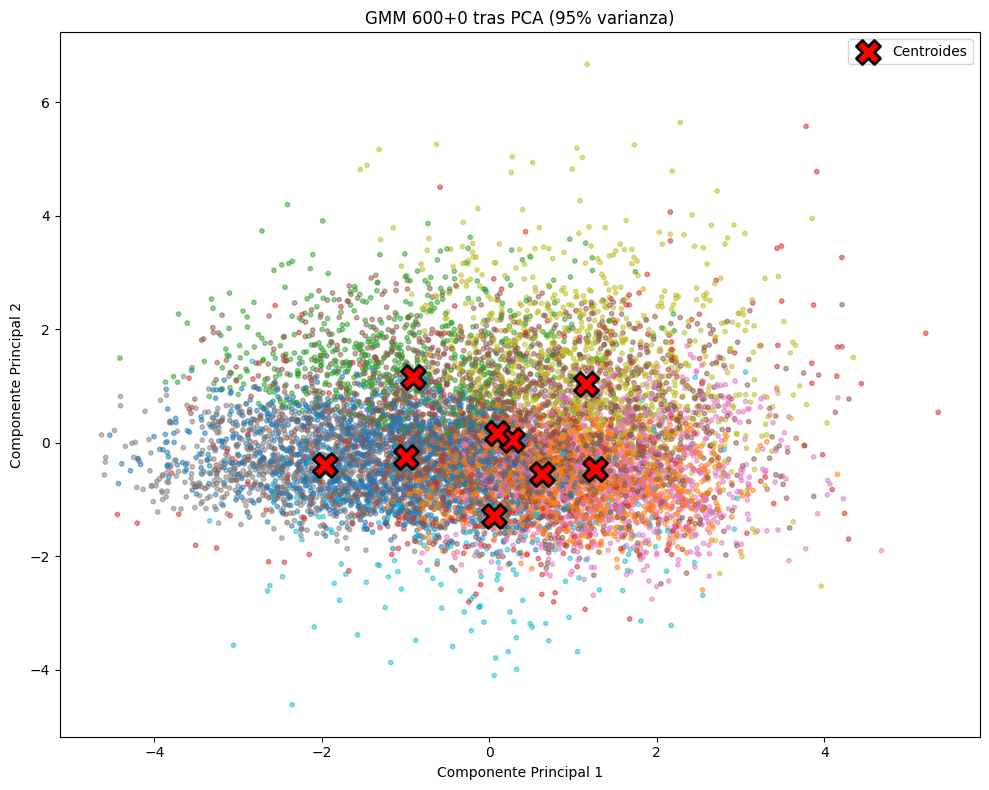

In [56]:
pca(df_600_ext_sample, 9, 0.95, 'GMM 600+0 tras PCA (95% varianza)', nombre_archivo = 'gmm_600_ext_pca_095.png')

PCA 0.80:

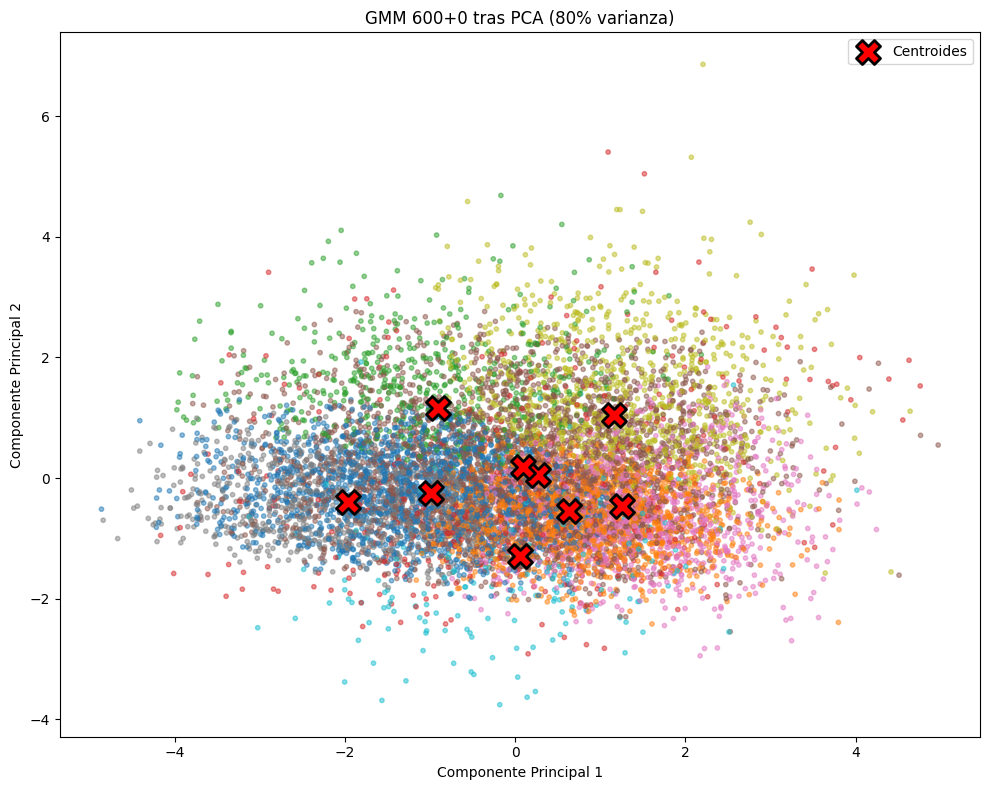

In [57]:
pca(df_600_ext_sample, 9, 0.8, 'GMM 600+0 tras PCA (80% varianza)', nombre_archivo = 'gmm_600_ext_pca_080.png')